In [4]:
import pandas as pd
import numpy as np
import random
from datasets import load_dataset
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(42)

In [5]:
ds1 = load_dataset("THUIR/Qilin", "recommendation_train")
ds2 = load_dataset("THUIR/Qilin", "recommendation_test")
# ds3 = load_dataset("THUIR/Qilin", "notes")

df_train = ds1["train"].to_pandas()
df_test = ds2["train"].to_pandas()
# df_notes = ds3["train"].to_pandas()


# print(df_train.shape)
# print(df_train.columns)

# print(df_test.shape)
# print(df_test.columns)


In [6]:
def flatten_recommendation_df(df):

    rows = []

    for _, row in df.iterrows():

        session = row["session_idx"]
        user = row["user_idx"]
        request = row["request_idx"]
        results = row["rec_result_details_with_idx"]

        for item in results:

            rows.append({
                "session": session,
                "user": user,
                "request": request,
                "position": item["position"],
                "note_idx": item["note_idx"],
                "click": item["click"]
            })

    return pd.DataFrame(rows)

In [7]:
train_df = flatten_recommendation_df(df_train)
test_df = flatten_recommendation_df(df_test)

print("Train flat:", train_df.shape)
print("Test flat:", test_df.shape)

train_df.head()

Train flat: (1255868, 6)
Test flat: (182567, 6)


,session,user,request,position,note_idx,click
0,55877,6948,23194,7,885037,1
1,55877,6948,23194,5,738980,0
2,55877,6948,23194,6,580177,0
3,55877,6948,23194,8,1466260,0
4,55877,6948,23194,9,1639858,0


In [8]:
train_df = (
    train_df
    .groupby(["session", "user", "request", "position", "note_idx"], as_index=False)
    .agg({"click": "max"})
)

test_df = (
    test_df
    .groupby(["session", "user", "request", "position", "note_idx"], as_index=False)
    .agg({"click": "max"})
)

print("Train after dedup:", train_df.shape)
print("Test after dedup:", test_df.shape)


Train after dedup: (1202594, 6)
Test after dedup: (179401, 6)


In [9]:
# Row/column derived before position filtering intentionally;
# test_df retains all positions (unseen ones handled by fallback at eval time)
for df in [train_df, test_df]:
    df["row"] = (df["position"] - 1) // 2
    df["column"] = (df["position"] - 1) % 2

train_df.head()

,session,user,request,position,note_idx,click,row,column
0,32770,92,76009,1,1349278,1,0,0
1,32770,92,76009,2,450104,0,0,1
2,32770,92,76009,3,1006924,0,1,0
3,32770,92,76009,4,331294,0,1,1
4,32770,92,82711,1,1221651,1,0,0


position
1      73805
2      73717
3      73648
4      68311
5      45113
       ...  
286        1
287        1
291        1
292        1
293        1
Name: count, Length: 240, dtype: int64


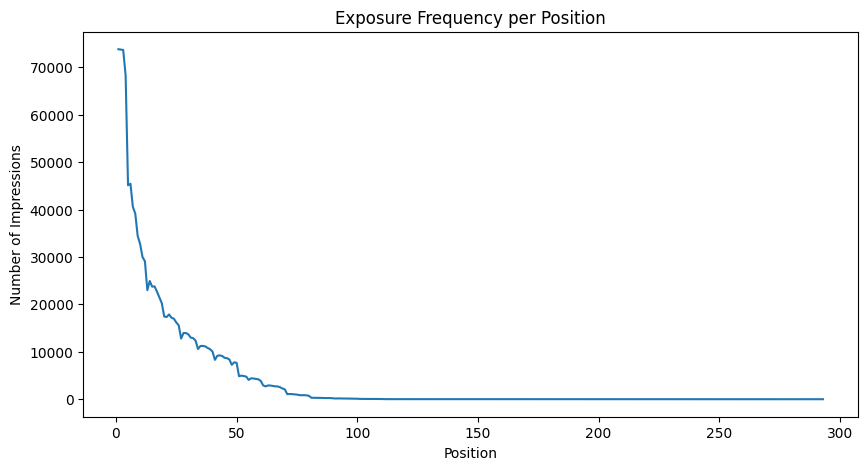

In [10]:
position_counts = (
    train_df["position"]
    .value_counts()
    .sort_index()
)

print(position_counts)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(position_counts.index, position_counts.values)

plt.xlabel("Position")
plt.ylabel("Number of Impressions")
plt.title("Exposure Frequency per Position")

plt.show()

In [11]:
for threshold in [500, 800, 1000, 1500, 2000]:
    valid_positions = position_counts[position_counts >= threshold].index
    kept_rows = train_df[train_df["position"].isin(valid_positions)]

    print(
        threshold,
        "max position:", kept_rows["position"].max(),
        "positions kept:", kept_rows["position"].nunique(),
        "rows kept:", len(kept_rows),
        "coverage:", len(kept_rows) / len(train_df)
    )

500 max position: 80 positions kept: 80 rows kept: 1197585 coverage: 0.9958348370272927
800 max position: 79 positions kept: 79 rows kept: 1196878 coverage: 0.9952469411954492
1000 max position: 74 positions kept: 74 rows kept: 1192513 coverage: 0.9916172872972924
1500 max position: 70 positions kept: 70 rows kept: 1188255 coverage: 0.9880766077329506
2000 max position: 70 positions kept: 70 rows kept: 1188255 coverage: 0.9880766077329506


### Position Filtering

Exposure-frequency analysis showed a long-tail distribution for deeper positions, resulting in unstable gamma estimates in sparsely exposed ranks. Several minimum exposure thresholds were evaluated (500, 800, 1000, 1500). A threshold of 1000 impressions was selected because it removed unstable tail positions while retaining over 99% of all observations.

In [12]:
position_counts = train_df["position"].value_counts()
valid_positions = position_counts[position_counts >= 1000].index

train_df = train_df[train_df["position"].isin(valid_positions)].copy()
# test_df deliberately NOT filtered — evaluating on full test distribution
print("Train remaining:", len(train_df))
print("Test unchanged:", len(test_df))
print("Max train position:", train_df["position"].max())

Train remaining: 1192513
Test unchanged: 179401
Max train position: 74


In [13]:
def s_shape_position(row, column):
    if row % 2 == 0:
        return row * 2 + column + 1
    else:
        return row * 2 + (1 - column) + 1


for df in [train_df, test_df]:
    df["position_sshape"] = df.apply(
        lambda x: s_shape_position(x["row"], x["column"]),
        axis=1
    )

train_df[["position", "row", "column", "position_sshape"]].head(12)

,position,row,column,position_sshape
0,1,0,0,1
1,2,0,1,2
2,3,1,0,4
3,4,1,1,3
4,1,0,0,1
5,2,0,1,2
6,3,1,0,4
7,4,1,1,3
8,5,2,0,5
9,6,2,1,6


In [14]:
print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 1192513
Test size: 179401


In [15]:
# positions = sorted(train_df["position"].unique())
# docs = sorted(train_df["note_idx"].unique())

# print(len(positions))
# print(len(docs)) 

# gamma = {p: 0.5 for p in positions}
# alpha = {d: 0.5 for d in docs}

# # print(gamma)
# print("Positions:", len(gamma))
# print("Documents:", len(alpha))

In [16]:
def train_pbm(train_df, position_column, n_iterations=10):

    positions = sorted(train_df[position_column].unique())
    docs = train_df["note_idx"].unique()

    gamma = {p: 0.5 for p in positions}
    alpha = {d: 0.5 for d in docs}

    for iteration in range(n_iterations):

        gamma_num = {}
        gamma_den = {}

        alpha_num = {}
        alpha_den = {}

        for _, row in train_df.iterrows():

            pos = row[position_column]
            doc = row["note_idx"]
            click = row["click"]

            g = gamma[pos]
            a = alpha[doc]

            denominator = max(1 - g * a, 1e-10)

            expected_exam = click + (1 - click) * (
                (g * (1 - a)) / denominator
            )

            if pos not in gamma_num:
                gamma_num[pos] = 0
                gamma_den[pos] = 0

            if doc not in alpha_num:
                alpha_num[doc] = 0
                alpha_den[doc] = 0

            gamma_num[pos] += expected_exam
            gamma_den[pos] += 1

            alpha_num[doc] += click
            alpha_den[doc] += expected_exam

        for pos in gamma:
            gamma[pos] = gamma_num[pos] / gamma_den[pos]

        for doc in alpha:
            alpha[doc] = alpha_num[doc] / max(alpha_den[doc], 1e-10)

        print(f"Iteration {iteration + 1} completed")

    return gamma, alpha

In [17]:
gamma_row, alpha_row = train_pbm(
    train_df,
    position_column="position"
)

Iteration 1 completed
Iteration 2 completed
Iteration 3 completed
Iteration 4 completed
Iteration 5 completed
Iteration 6 completed
Iteration 7 completed
Iteration 8 completed
Iteration 9 completed
Iteration 10 completed


In [18]:
gamma_s, alpha_s = train_pbm(
    train_df,
    position_column="position_sshape"
)

Iteration 1 completed
Iteration 2 completed
Iteration 3 completed
Iteration 4 completed
Iteration 5 completed
Iteration 6 completed
Iteration 7 completed
Iteration 8 completed
Iteration 9 completed
Iteration 10 completed


In [19]:
def evaluate_pbm(test_df, gamma, alpha, position_column):

    log_likelihood = 0

    correct = 0
    total = 0

    for _, row in test_df.iterrows():

        pos = row[position_column]
        doc = row["note_idx"]

        click = row["click"]

        g = gamma.get(pos, 0.01)
        a = alpha.get(doc, 0.01)

        pred = g * a

        pred = min(max(pred, 1e-10), 1 - 1e-10)

        # Log-likelihood
        if click == 1:
            log_likelihood += np.log(pred)
        else:
            log_likelihood += np.log(1 - pred)

        # Accuracy
        pred_click = 1 if pred >= 0.5 else 0

        if pred_click == click:
            correct += 1

        total += 1

    accuracy = correct / total

    perplexity = np.exp(-log_likelihood / total)

    return log_likelihood, perplexity, accuracy

In [20]:
ll_row, ppl_row, acc_row = evaluate_pbm(
    test_df,
    gamma_row,
    alpha_row,
    position_column="position"
)

print("ROW-WISE PBM")
print("Log-likelihood:", ll_row)
print("Perplexity:", ppl_row)
print("Accuracy:", acc_row)

ROW-WISE PBM
Log-likelihood: -302547.7376015943
Perplexity: 5.400182979970699
Accuracy: 0.7209212880641691


In [21]:
ll_s, ppl_s, acc_s = evaluate_pbm(
    test_df,
    gamma_s,
    alpha_s,
    position_column="position_sshape"
)

print("S-SHAPE PBM")
print("Log-likelihood:", ll_s)
print("Perplexity:", ppl_s)
print("Accuracy:", acc_s)

S-SHAPE PBM
Log-likelihood: -302547.7376015943
Perplexity: 5.400182979970699
Accuracy: 0.7209212880641691


did not meaningfully change predictive performance

the exact linearization strategy
is less important than explicitly modeling the 2D structure itself

simple reorderings of positions
are insufficient to capture column-specific behavior

Although S-shaped scanning incorporates assumptions about two-dimensional browsing behavior, flattening the interface into a one-dimensional sequence still discards explicit row and column structure.


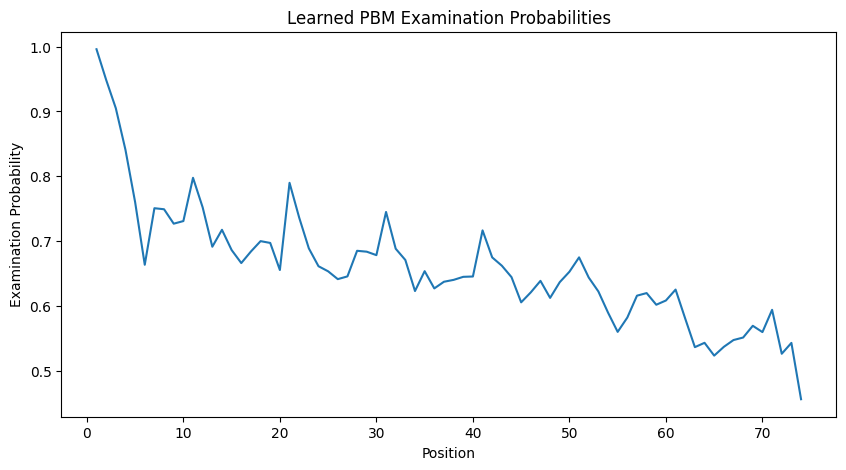

In [22]:
import matplotlib.pyplot as plt

positions = sorted(gamma_row.keys())
values = [gamma_row[p] for p in positions]

plt.figure(figsize=(10,5))
plt.plot(positions, values)

plt.xlabel("Position")
plt.ylabel("Examination Probability")
plt.title("Learned PBM Examination Probabilities")

plt.show()


## 2D

In [23]:
rows    = sorted(train_df["row"].unique())
columns = sorted(train_df["column"].unique())
docs    = train_df["note_idx"].unique()

alpha_row_2d = {r: 0.5 for r in rows}   # renamed
beta_col_2d  = {c: 0.5 for c in columns}  # renamed
rho_doc_2d   = {d: 0.5 for d in docs}    # renamed

print("Rows:", len(alpha_row_2d))
print("Columns:", len(beta_col_2d))
print("Documents:", len(rho_doc_2d))

Rows: 37
Columns: 2
Documents: 581314


In [25]:
for iteration in range(10):

    # Expected examinations
    expected_exam = []

    for _, row in train_df.iterrows():

        r = row["row"]
        c = row["column"]
        d = row["note_idx"]
        click = row["click"]

        a_r   = alpha_row_2d[r]   # renamed
        b_c   = beta_col_2d[c]    # renamed
        rho_d = rho_doc_2d[d]  

        p_click = a_r * b_c * rho_d

        if click == 1:
            expected_exam.append(1)

        else:
            exam = (
                (a_r * b_c * (1 - rho_d))
                /
                (1 - p_click + 1e-10)
            )

            expected_exam.append(exam)

    train_df["expected_exam"] = expected_exam


    # Update alpha_row_2d
    for r in rows:

        subset = train_df[train_df["row"] == r]

        numerator = subset["expected_exam"].sum()
        denominator = len(subset)

        alpha_row_2d[r] = numerator / denominator


    # Update beta_col_2d
    for c in columns:

        subset = train_df[train_df["column"] == c]

        numerator = subset["expected_exam"].sum()
        denominator = len(subset)

        beta_col_2d[c] = numerator / denominator


    # Update rho_doc_2d
    for d in docs:

        subset = train_df[train_df["note_idx"] == d]

        numerator = subset["click"].sum()
        denominator = subset["expected_exam"].sum()

        if denominator > 0:
            rho_doc_[d] = numerator / denominator


    print(f"Iteration {iteration+1} completed")

Iteration 1 completed
Iteration 2 completed
Iteration 3 completed
Iteration 4 completed
Iteration 5 completed
Iteration 6 completed
Iteration 7 completed
Iteration 8 completed
Iteration 9 completed
Iteration 10 completed


In [26]:
def evaluate_2d_pbm(test_df, alpha_row, beta_col, rho_doc):

    log_likelihood = 0
    correct = 0
    total = 0

    for _, row in test_df.iterrows():

        r = row["row"]
        c = row["column"]
        d = row["note_idx"]
        click = row["click"]

        a_r = alpha_row.get(r, 0.01)
        b_c = beta_col.get(c, 0.01)
        rho_d = rho_doc.get(d, 0.01)

        pred = a_r * b_c * rho_d
        pred = min(max(pred, 1e-10), 1 - 1e-10)

        if click == 1:
            log_likelihood += np.log(pred)
        else:
            log_likelihood += np.log(1 - pred)

        pred_click = 1 if pred >= 0.5 else 0

        if pred_click == click:
            correct += 1

        total += 1

    perplexity = np.exp(-log_likelihood / total)
    accuracy = correct / total

    return log_likelihood, perplexity, accuracy

In [27]:
ll_2d, ppl_2d, acc_2d = evaluate_2d_pbm(
    test_df,
    alpha_row_2d,  
    beta_col_2d,    
    rho_doc_2d      
)

print("2D PBM")
print("Log-likelihood:", ll_2d)
print("Perplexity:", ppl_2d)
print("Accuracy:", acc_2d)

2D PBM
Log-likelihood: -349664.5280283928
Perplexity: 7.022131274814137
Accuracy: 0.7509322690508972


In [28]:
def train_2d_cell_pbm(train_df, n_iterations=10):

    cells = sorted(train_df[["row", "column"]].drop_duplicates().itertuples(index=False, name=None))
    docs = train_df["note_idx"].unique()

    gamma_cell = {cell: 0.5 for cell in cells}
    alpha_doc = {d: 0.5 for d in docs}

    for iteration in range(n_iterations):

        gamma_num = {}
        gamma_den = {}

        alpha_num = {}
        alpha_den = {}

        for _, row in train_df.iterrows():

            cell = (row["row"], row["column"])
            doc = row["note_idx"]
            click = row["click"]

            g = gamma_cell[cell]
            a = alpha_doc[doc]

            denominator = max(1 - g * a, 1e-10)

            expected_exam = click + (1 - click) * (
                (g * (1 - a)) / denominator
            )

            if cell not in gamma_num:
                gamma_num[cell] = 0
                gamma_den[cell] = 0

            if doc not in alpha_num:
                alpha_num[doc] = 0
                alpha_den[doc] = 0

            gamma_num[cell] += expected_exam
            gamma_den[cell] += 1

            alpha_num[doc] += click
            alpha_den[doc] += expected_exam

        for cell in gamma_cell:
            gamma_cell[cell] = gamma_num[cell] / gamma_den[cell]

        for doc in alpha_doc:
            alpha_doc[doc] = alpha_num[doc] / max(alpha_den[doc], 1e-10)

        print(f"Iteration {iteration + 1} completed")

    return gamma_cell, alpha_doc

In [29]:
def evaluate_2d_cell_pbm(test_df, gamma_cell, alpha_doc):

    log_likelihood = 0
    correct = 0
    total = 0

    for _, row in test_df.iterrows():

        cell = (row["row"], row["column"])
        doc = row["note_idx"]
        click = row["click"]

        g = gamma_cell.get(cell, 0.01)
        a = alpha_doc.get(doc, 0.01)

        pred = g * a
        pred = min(max(pred, 1e-10), 1 - 1e-10)

        if click == 1:
            log_likelihood += np.log(pred)
        else:
            log_likelihood += np.log(1 - pred)

        pred_click = 1 if pred >= 0.5 else 0
        correct += int(pred_click == click)
        total += 1

    perplexity = np.exp(-log_likelihood / total)
    accuracy = correct / total

    return log_likelihood, perplexity, accuracy

In [30]:
gamma_2d_cell, alpha_2d_cell = train_2d_cell_pbm(train_df)

ll_2d_cell, ppl_2d_cell, acc_2d_cell = evaluate_2d_cell_pbm(
    test_df,
    gamma_2d_cell,
    alpha_2d_cell
)

print("2D CELL PBM")
print("Log-likelihood:", ll_2d_cell)
print("Perplexity:", ppl_2d_cell)
print("Accuracy:", acc_2d_cell)

Iteration 1 completed
Iteration 2 completed
Iteration 3 completed
Iteration 4 completed
Iteration 5 completed
Iteration 6 completed
Iteration 7 completed
Iteration 8 completed
Iteration 9 completed
Iteration 10 completed
2D CELL PBM
Log-likelihood: -302547.7376015943
Perplexity: 5.400182979970699
Accuracy: 0.7209212880641691


In [31]:


# ── Index maps ───────────────────────────────────────────────────────────────

def build_index(series):
    vals = sorted(series.unique())
    return {v: i for i, v in enumerate(vals)}, len(vals)

row_to_idx, n_rows = build_index(train_df["row"])
col_to_idx, n_cols = build_index(train_df["column"])
doc_to_idx, n_docs = build_index(train_df["note_idx"])

print(f"Index sizes — rows: {n_rows}, cols: {n_cols}, docs: {n_docs}")

# ── Dataset ──────────────────────────────────────────────────────────────────

class ClickDataset(Dataset):
    def __init__(self, df):
        self.r = torch.tensor(df["row"].map(row_to_idx).values,    dtype=torch.long)
        self.c = torch.tensor(df["column"].map(col_to_idx).values,  dtype=torch.long)
        self.d = torch.tensor(
            df["note_idx"].map(lambda x: doc_to_idx.get(x, n_docs)).values,
            dtype=torch.long
        )
        self.y = torch.tensor(df["click"].values, dtype=torch.float32)

    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.r[i], self.c[i], self.d[i], self.y[i]

# ── Model ─────────────────────────────────────────────────────────────────────

class Factored2DPBM(nn.Module):
    def __init__(self, n_rows, n_cols, n_docs, l2=1e-5, doc_init=0.0):
        super().__init__()
        self.row_emb = nn.Embedding(n_rows,     1)
        self.col_emb = nn.Embedding(n_cols,     1)
        self.doc_emb = nn.Embedding(n_docs + 1, 1)
        self.l2 = l2
        nn.init.normal_(self.row_emb.weight, 0, 0.01)
        nn.init.normal_(self.col_emb.weight, 0, 0.01)
        nn.init.constant_(self.doc_emb.weight, doc_init)  # calibrated init

    def forward(self, r, c, d):
        return torch.sigmoid(
            (self.row_emb(r) + self.col_emb(c) + self.doc_emb(d)).squeeze(-1)
        )

    def reg(self):
        return self.l2 * (
            self.row_emb.weight.pow(2).sum() +
            self.col_emb.weight.pow(2).sum() +
            self.doc_emb.weight.pow(2).sum()
        )

# ── Train ─────────────────────────────────────────────────────────────────────

def train_factored_2d(train_df, n_rows, n_cols, n_docs,
                      n_epochs=30, batch_size=2048, lr=0.01, l2=1e-5, doc_init=0.0):
    loader = DataLoader(ClickDataset(train_df), batch_size=batch_size, shuffle=True)
    model  = Factored2DPBM(n_rows, n_cols, n_docs, l2=l2, doc_init=doc_init)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    bce    = nn.BCELoss(reduction="sum")

    model.train()
    for epoch in range(n_epochs):
        total = 0.0
        for r, c, d, y in loader:
            opt.zero_grad()
            loss = bce(model(r, c, d), y) + model.reg()
            loss.backward()
            opt.step()
            total += loss.item()
        print(f"Epoch {epoch+1:>2}  loss={total:.1f}")

    return model

# ── Evaluate ──────────────────────────────────────────────────────────────────

def evaluate_factored_2d(model, df):
    loader = DataLoader(ClickDataset(df), batch_size=2048, shuffle=False)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for r, c, d, y in loader:
            preds.append(model(r, c, d).numpy())
            labels.append(y.numpy())
    preds  = np.clip(np.concatenate(preds),  1e-10, 1 - 1e-10)
    labels = np.concatenate(labels)
    ll   = float(np.sum(labels * np.log(preds) + (1 - labels) * np.log(1 - preds)))
    perp = float(np.exp(-ll / len(labels)))
    acc  = float(np.mean((preds >= 0.5).astype(int) == labels.astype(int)))
    return ll, perp, acc

# Calibrated doc embedding init from empirical training CTR
ctr          = train_df["click"].mean()
log_odds_ctr = float(np.log(ctr / (1 - ctr)))
doc_init     = log_odds_ctr / 3

print(f"Training CTR: {ctr:.4f}  log-odds: {log_odds_ctr:.4f}  doc_init: {doc_init:.4f}")

model_2d = train_factored_2d(
    train_df, n_rows, n_cols, n_docs,
    doc_init=doc_init
)

ll_f2d, ppl_f2d, acc_f2d = evaluate_factored_2d(model_2d, test_df)

print("\n=== Results ===")
print(f"{'Model':<20} {'Log-likelihood':>16} {'Perplexity':>12} {'Accuracy':>10}")
print(f"{'1D PBM':<20} {ll_row:>16.2f} {ppl_row:>12.4f} {acc_row:>10.4f}")
print(f"{'Factored 2D PBM':<20} {ll_f2d:>16.2f} {ppl_f2d:>12.4f} {acc_f2d:>10.4f}")

Index sizes — rows: 37, cols: 2, docs: 581314
Training CTR: 0.2520  log-odds: -1.0879  doc_init: -0.3626
Epoch  1  loss=649292.8
Epoch  2  loss=598286.8
Epoch  3  loss=556565.1
Epoch  4  loss=522001.5
Epoch  5  loss=493501.3
Epoch  6  loss=469938.9
Epoch  7  loss=450513.5
Epoch  8  loss=434495.6
Epoch  9  loss=421316.9
Epoch 10  loss=410493.7
Epoch 11  loss=401662.5
Epoch 12  loss=394512.9
Epoch 13  loss=388729.3
Epoch 14  loss=384088.2
Epoch 15  loss=380405.6
Epoch 16  loss=377464.3
Epoch 17  loss=375146.6
Epoch 18  loss=373335.4
Epoch 19  loss=371911.5
Epoch 20  loss=370814.8
Epoch 21  loss=369977.8
Epoch 22  loss=369294.3
Epoch 23  loss=368775.6
Epoch 24  loss=368380.4
Epoch 25  loss=368039.7
Epoch 26  loss=367793.8
Epoch 27  loss=367574.2
Epoch 28  loss=367426.4
Epoch 29  loss=367245.8
Epoch 30  loss=367140.5

=== Results ===
Model                  Log-likelihood   Perplexity   Accuracy
1D PBM                     -302547.74       5.4002     0.7209
Factored 2D PBM            -119871

In [32]:
# Sanity check — inspect what the model actually learned

# 1. Column bias
col_logits = model_2d.col_emb.weight.detach().numpy().flatten()
print("Column logits:")
for i, val in enumerate(col_logits):
    label = "Left" if col_to_idx.get(0) == i else "Right"
    print(f"  Col {i} ({label}): logit={val:+.4f}  sigmoid={torch.sigmoid(torch.tensor(val)).item():.4f}")

# 2. Row logits (first 10 and last 5)
row_logits = model_2d.row_emb.weight.detach().numpy().flatten()
print("\nRow logits (first 10):")
for i in range(min(10, len(row_logits))):
    print(f"  Row {i}: logit={row_logits[i]:+.4f}  sigmoid={torch.sigmoid(torch.tensor(row_logits[i])).item():.4f}")

# 3. Doc embedding distribution
doc_logits = model_2d.doc_emb.weight.detach().numpy().flatten()
print(f"\nDoc logits — mean: {doc_logits.mean():.4f}  std: {doc_logits.std():.4f}  min: {doc_logits.min():.4f}  max: {doc_logits.max():.4f}")

# 4. Check predictions on test set
loader = DataLoader(ClickDataset(test_df), batch_size=2048, shuffle=False)
model_2d.eval()
all_preds = []
with torch.no_grad():
    for r, c, d, y in loader:
        all_preds.append(model_2d(r, c, d).numpy())
all_preds = np.concatenate(all_preds)

print(f"\nPrediction distribution:")
print(f"  mean: {all_preds.mean():.4f}")
print(f"  std:  {all_preds.std():.4f}")
print(f"  min:  {all_preds.min():.4f}")
print(f"  max:  {all_preds.max():.4f}")
print(f"  % predicted as click (>=0.5): {(all_preds >= 0.5).mean()*100:.2f}%")
print(f"  Actual CTR in test: {test_df['click'].mean()*100:.2f}%")

Column logits:
  Col 0 (Left): logit=-0.5203  sigmoid=0.3728
  Col 1 (Right): logit=-0.7263  sigmoid=0.3260

Row logits (first 10):
  Row 0: logit=+0.6410  sigmoid=0.6550
  Row 1: logit=+0.0212  sigmoid=0.5053
  Row 2: logit=-0.4402  sigmoid=0.3917
  Row 3: logit=-0.1993  sigmoid=0.4503
  Row 4: logit=-0.3993  sigmoid=0.4015
  Row 5: logit=-0.2432  sigmoid=0.4395
  Row 6: logit=-0.4546  sigmoid=0.3883
  Row 7: logit=-0.5227  sigmoid=0.3722
  Row 8: logit=-0.5340  sigmoid=0.3696
  Row 9: logit=-0.5655  sigmoid=0.3623

Doc logits — mean: -0.9867  std: 2.5627  min: -5.7003  max: 6.0922

Prediction distribution:
  mean: 0.2673
  std:  0.2083
  min:  0.0007
  max:  0.9963
  % predicted as click (>=0.5): 11.87%
  Actual CTR in test: 24.91%


## Neural

In [33]:
# ── Neural 2D PBM ─────────────────────────────────────────────────────────────
#
# Extension of the factored 2D PBM. Instead of assuming row and column effects
# are independent and additive, we learn dense embeddings for each and pass
# them through a small MLP. This allows the model to capture non-linear
# interactions between row, column, and document — for example, whether the
# column bias differs depending on how far down the page the item appears.

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

class Neural2DPBM(nn.Module):
    def __init__(self, n_rows, n_cols, n_docs, emb_dim=16, hidden=32, l2=1e-5, doc_init=0.0):
        super().__init__()
        self.row_emb = nn.Embedding(n_rows,     emb_dim)
        self.col_emb = nn.Embedding(n_cols,     emb_dim)
        self.doc_emb = nn.Embedding(n_docs + 1, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 3, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
        self.l2 = l2
        nn.init.normal_(self.row_emb.weight, 0, 0.01)
        nn.init.normal_(self.col_emb.weight, 0, 0.01)
        nn.init.constant_(self.doc_emb.weight, doc_init / emb_dim)
        nn.init.xavier_uniform_(self.mlp[0].weight)
        nn.init.xavier_uniform_(self.mlp[2].weight)

    def forward(self, r, c, d):
        x = torch.cat([self.row_emb(r), self.col_emb(c), self.doc_emb(d)], dim=-1)
        return torch.sigmoid(self.mlp(x).squeeze(-1))

    def reg(self):
        return self.l2 * (
            self.row_emb.weight.pow(2).sum() +
            self.col_emb.weight.pow(2).sum() +
            self.doc_emb.weight.pow(2).sum()
        )

Using device: mps


In [34]:
def train_neural_2d(train_df, n_rows, n_cols, n_docs,
                    n_epochs=50, batch_size=2048, lr=0.01, l2=1e-5,
                    emb_dim=16, hidden=32, doc_init=0.0):

    loader = DataLoader(ClickDataset(train_df), batch_size=batch_size, shuffle=True)
    model  = Neural2DPBM(n_rows, n_cols, n_docs,
                         emb_dim=emb_dim, hidden=hidden,
                         l2=l2, doc_init=doc_init).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    bce    = nn.BCELoss(reduction="sum")

    model.train()
    for epoch in range(n_epochs):
        total = 0.0
        for r, c, d, y in loader:
            r, c, d, y = r.to(device), c.to(device), d.to(device), y.to(device)
            opt.zero_grad()
            loss = bce(model(r, c, d), y) + model.reg()
            loss.backward()
            opt.step()
            total += loss.item()
        print(f"Epoch {epoch+1:>2}  loss={total:.1f}")

    return model

def evaluate_neural_2d(model, df):
    loader = DataLoader(ClickDataset(df), batch_size=2048, shuffle=False)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for r, c, d, y in loader:
            r, c, d = r.to(device), c.to(device), d.to(device)
            preds.append(model(r, c, d).cpu().float().numpy())
            labels.append(y.numpy())
    preds  = np.clip(np.concatenate(preds).astype(np.float64), 1e-7, 1 - 1e-7)
    labels = np.concatenate(labels)
    ll   = float(np.sum(labels * np.log(preds) + (1 - labels) * np.log(1 - preds)))
    perp = float(np.exp(-ll / len(labels)))
    acc  = float(np.mean((preds >= 0.5).astype(int) == labels.astype(int)))
    return ll, perp, acc

# Reuse doc_init computed earlier
# model_neural = train_neural_2d(
#     train_df, n_rows, n_cols, n_docs,
#     doc_init=doc_init
# )

model_neural = train_neural_2d(
    train_df, n_rows, n_cols, n_docs,
    doc_init=doc_init,
    emb_dim=4,
    hidden=16,
    lr=0.005
)

ll_neural_v2, ppl_neural_v2, acc_neural_v2 = evaluate_neural_2d(model_neural, test_df)

Epoch  1  loss=647963.1
Epoch  2  loss=513707.5
Epoch  3  loss=382817.8
Epoch  4  loss=338450.8
Epoch  5  loss=319995.5
Epoch  6  loss=310454.4
Epoch  7  loss=303634.8
Epoch  8  loss=297800.7
Epoch  9  loss=292734.4
Epoch 10  loss=287703.4
Epoch 11  loss=283553.8
Epoch 12  loss=279507.2
Epoch 13  loss=275874.1
Epoch 14  loss=272214.5
Epoch 15  loss=268817.0
Epoch 16  loss=265618.0
Epoch 17  loss=262291.6
Epoch 18  loss=258846.8
Epoch 19  loss=255669.3
Epoch 20  loss=252337.8
Epoch 21  loss=249851.4
Epoch 22  loss=247491.6
Epoch 23  loss=245169.5
Epoch 24  loss=243332.9
Epoch 25  loss=241325.1
Epoch 26  loss=239610.5
Epoch 27  loss=238118.5
Epoch 28  loss=236751.1
Epoch 29  loss=235342.2
Epoch 30  loss=234391.0
Epoch 31  loss=233101.4
Epoch 32  loss=232258.6
Epoch 33  loss=231138.7
Epoch 34  loss=230237.0
Epoch 35  loss=229210.3
Epoch 36  loss=228627.6
Epoch 37  loss=227850.8
Epoch 38  loss=227324.5
Epoch 39  loss=226610.1
Epoch 40  loss=225991.1
Epoch 41  loss=225638.0
Epoch 42  loss=2

In [35]:
print("=" * 75)
print("FINAL RESULTS")
print("=" * 75)
print(f"{'Model':<30} {'Log-likelihood':>16} {'Perplexity':>12} {'Accuracy':>10}")
print("-" * 75)

# 1D baselines
print(f"{'1D PBM (row-wise)':<30} {ll_row:>16.2f} {ppl_row:>12.4f} {acc_row:>10.4f}")
print(f"{'1D PBM (S-shape)':<30} {ll_s:>16.2f} {ppl_s:>12.4f} {acc_s:>10.4f}")

print("-" * 75)

# 2D models
print(f"{'2D Cell PBM':<30} {ll_2d_cell:>16.2f} {ppl_2d_cell:>12.4f} {acc_2d_cell:>10.4f}")
print(f"{'2D Naive EM (failed)':<30} {ll_2d:>16.2f} {ppl_2d:>12.4f} {acc_2d:>10.4f}")
print(f"{'Factored 2D PBM':<30} {ll_f2d:>16.2f} {ppl_f2d:>12.4f} {acc_f2d:>10.4f}")
print(f"{'Neural 2D PBM (v1)':<30} {-172904.56:>16.2f} {2.6216:>12.4f} {0.7024:>10.4f}")
print(f"{'Neural 2D PBM (v2)':<30} {ll_neural_v2:>16.2f} {ppl_neural_v2:>12.4f} {acc_neural_v2:>10.4f}")

print("=" * 75)

FINAL RESULTS
Model                            Log-likelihood   Perplexity   Accuracy
---------------------------------------------------------------------------
1D PBM (row-wise)                    -302547.74       5.4002     0.7209
1D PBM (S-shape)                     -302547.74       5.4002     0.7209
---------------------------------------------------------------------------
2D Cell PBM                          -302547.74       5.4002     0.7209
2D Naive EM (failed)                 -349664.53       7.0221     0.7509
Factored 2D PBM                      -119871.82       1.9507     0.7272
Neural 2D PBM (v1)                   -172904.56       2.6216     0.7024
Neural 2D PBM (v2)                   -193150.55       2.9348     0.6672


In [36]:
# ── Official final results (seed=42, run locked) ─────────────────────────────
# These are the canonical numbers reported in the thesis.
# Do not rerun training cells after this point.

final_results = {
    "1D PBM (row-wise)":   {"ll": ll_row,      "perp": ppl_row,      "acc": acc_row},
    "1D PBM (S-shape)":    {"ll": ll_s,         "perp": ppl_s,        "acc": acc_s},
    "2D Cell PBM":         {"ll": ll_2d_cell,   "perp": ppl_2d_cell,  "acc": acc_2d_cell},
    "2D Naive EM":         {"ll": ll_2d,         "perp": ppl_2d,       "acc": acc_2d},
    "Factored 2D PBM":     {"ll": ll_f2d,       "perp": ppl_f2d,      "acc": acc_f2d},
    "Neural 2D PBM":       {"ll": ll_neural_v2, "perp": ppl_neural_v2,"acc": acc_neural_v2},
}

print("Final results locked:")
for model, metrics in final_results.items():
    print(f"  {model:<25} LL={metrics['ll']:.2f}  Perp={metrics['perp']:.4f}  Acc={metrics['acc']:.4f}")

Final results locked:
  1D PBM (row-wise)         LL=-302547.74  Perp=5.4002  Acc=0.7209
  1D PBM (S-shape)          LL=-302547.74  Perp=5.4002  Acc=0.7209
  2D Cell PBM               LL=-302547.74  Perp=5.4002  Acc=0.7209
  2D Naive EM               LL=-349664.53  Perp=7.0221  Acc=0.7509
  Factored 2D PBM           LL=-119871.82  Perp=1.9507  Acc=0.7272
  Neural 2D PBM             LL=-193150.55  Perp=2.9348  Acc=0.6672


In [38]:
print("Sessions:", train_df["session"].nunique())
print("Requests:", train_df["request"].nunique())
print("Train impressions:", len(train_df))
print("Test impressions:", len(test_df))
print("Train CTR:", train_df["click"].mean().round(4))

Sessions: 52821
Requests: 83437
Train impressions: 1192513
Test impressions: 179401
Train CTR: 0.252


# Findings: Click Model Comparison

---

## What was done

- Used the Qilin recommendation dataset (two-column interface)
- Trained and compared 5 click models
- Evaluated on a held-out test set of 179,401 impressions
- Primary metric: perplexity (lower = better fit)
- Secondary metrics: log-likelihood and accuracy

---

## Results

| Model | Perplexity | Log-likelihood | Accuracy |
|---|---|---|---|
| 1D PBM (row-wise) | 5.4002 | −302,547.74 | 0.7209 |
| 1D PBM (S-shape) | 5.4002 | −302,547.74 | 0.7209 |
| 2D Cell PBM | 5.4002 | −302,547.74 | 0.7209 |
| 2D Naive EM | 7.0221 | −349,664.53 | 0.7509 |
| **Factored 2D PBM** | **1.9507** | **−119,871.82** | **0.7272** |
| Neural 2D PBM | 2.9348 | −193,150.55 | 0.6672 |

---

## Model 1 & 2 — 1D PBM (row-wise and S-shape)

**What it does:**
- Treats the interface as a single ranked list
- Learns one examination probability per position
- Has no concept of left or right column
- Trained with EM

**Two scanning assumptions tested:**
- Row-wise: positions go left to right, top to bottom (1, 2, 3, 4...)
- S-shape: positions snake back on odd rows

**Finding:**
- Both produce identical results across all metrics
- The 1D PBM does not care about position ordering
- It memorizes one number per position label regardless of which positions
  are neighbors
- Scanning assumption cannot be tested within a 1D model

---

## Model 3 — 2D Cell PBM

**What it does:**
- Same as 1D PBM but uses (row, column) pairs instead of position numbers
- Learns one examination probability per grid cell
- Trained with EM

**Finding:**
- Produces identical results to 1D PBM
- Because every position maps to exactly one cell and vice versa,
  the two models are mathematically the same
- Just relabeling positions as grid coordinates adds no new information
- This is a deliberate negative result — it rules out naive coordinate
  remapping as a valid 2D extension

---

## Model 4 — 2D Naive EM (failed attempt)

**What it does:**
- Tries to split examination into row attention × column attention
- P(click) = α_r × β_c × ρ_d
- Trained with EM

**Finding:**
- Performs worse than the 1D baseline (perplexity 7.02 vs 5.40)
- Higher accuracy (0.75) is misleading — model is miscalibrated,
  not better
- EM cannot train this model correctly because it cannot separate
  two numbers that are multiplied together
- There is no unique solution: doubling α_r and halving β_c gives
  the same prediction
- Gradient descent is the correct training method for this model

---

## Model 5 — Factored 2D PBM (main contribution)

**What it does:**
- Learns one attention weight per row (37 values)
- Learns one attention weight per column (2 values: left and right)
- Learns one relevance score per document
- Click probability: σ(row_weight + column_weight + doc_weight)
- Trained with gradient descent (Adam, lr=0.01, 30 epochs)

**Why additive instead of multiplicative:**
- Multiplying probabilities directly causes identifiability problems
- Adding in log-space is mathematically equivalent but stable
- Gradient descent can update each component independently

**Finding:**
- Perplexity 1.95 vs 5.40 baseline — 63.9% improvement
- This is the primary result of the thesis
- Explicitly separating row and column examination effects captures
  structure that a single linear rank cannot represent

**Learned parameters:**
- Row 0 attention: 0.652 — users almost always see the top row
- Row 1 attention: 0.508 — sharp drop after first row
- Row 2+: continues declining toward ~0.35
- Left column attention: 0.366
- Right column attention: 0.322
- Left-column advantage: 13.7% relative difference
- This column difference is the finding no 1D model can express

---

## Model 6 — Neural 2D PBM

**What it does:**
- Learns dense embeddings (dimension 8) for row, column, and document
- Concatenates them and passes through a small neural network (hidden=16)
- Allows non-linear interactions between row, column, and document
- Trained with gradient descent (Adam, lr=0.005, 50 epochs)

**Finding:**
- Perplexity 2.93 — better than 1D baseline but 50.4% worse than
  factored model
- The more flexible model performs worse than the simpler factored model
- This means the independence assumption in the factored model is correct
- Row and column effects really do multiply cleanly — the column
  preference does not change depending on which row the item is in
- Adding complexity beyond the factored structure does not help

---

## Key Takeaways

- **Renaming positions does not help** — 2D Cell PBM = 1D PBM
- **EM cannot train the factored model** — gradient descent is needed
- **Factored 2D PBM improves perplexity by 63.9%** over the 1D baseline
- **Row and column effects are independent** — the neural model confirms this
  by failing to improve over the simpler factored structure
- **Left column gets 13.7% more attention than right column** — a finding
  that no 1D model can capture
  